In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [3]:
#load dataset
housing = fetch_california_housing()
df= pd.DataFrame(housing.data, columns= housing.feature_names)
df['MedHouseVal'] = housing.target

print("shape:", df.shape)
print("\nFirst look:")
print(df.head())

shape: (20640, 9)

First look:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  



Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Describe:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00     

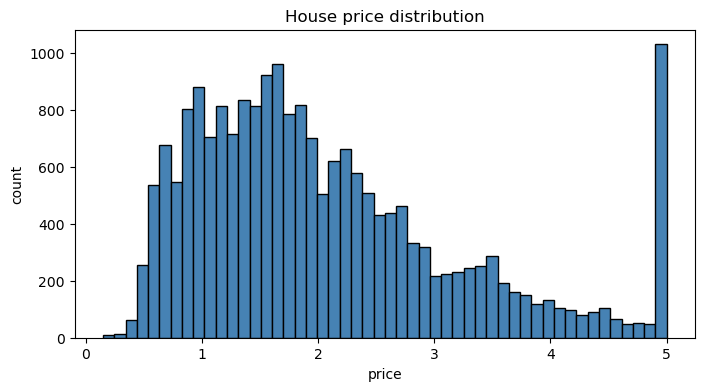

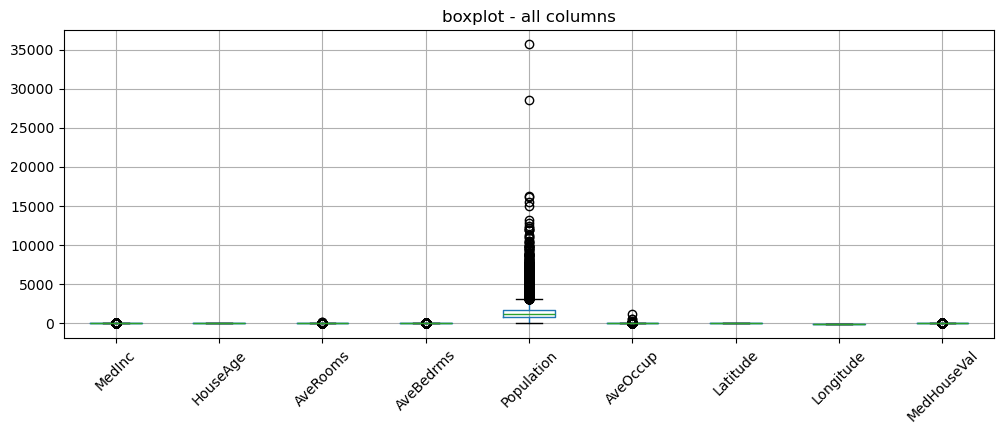

In [4]:
#univariate EDA
#missing values
print("\nMissing values:")
print(df.isnull().sum())

#basic stats
print("\nDescribe:")
print(df.describe().round(2))

#distribution of target (house price)
plt.figure(figsize=(8,4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black')
plt.title('House price distribution')
plt.xlabel('price')
plt.ylabel('count')
plt.show()

#boxplot for outliers
plt.figure(figsize=(12,4))
df.boxplot(figsize=(12,4))
plt.title('boxplot - all columns')
plt.xticks(rotation=45)
plt.show()

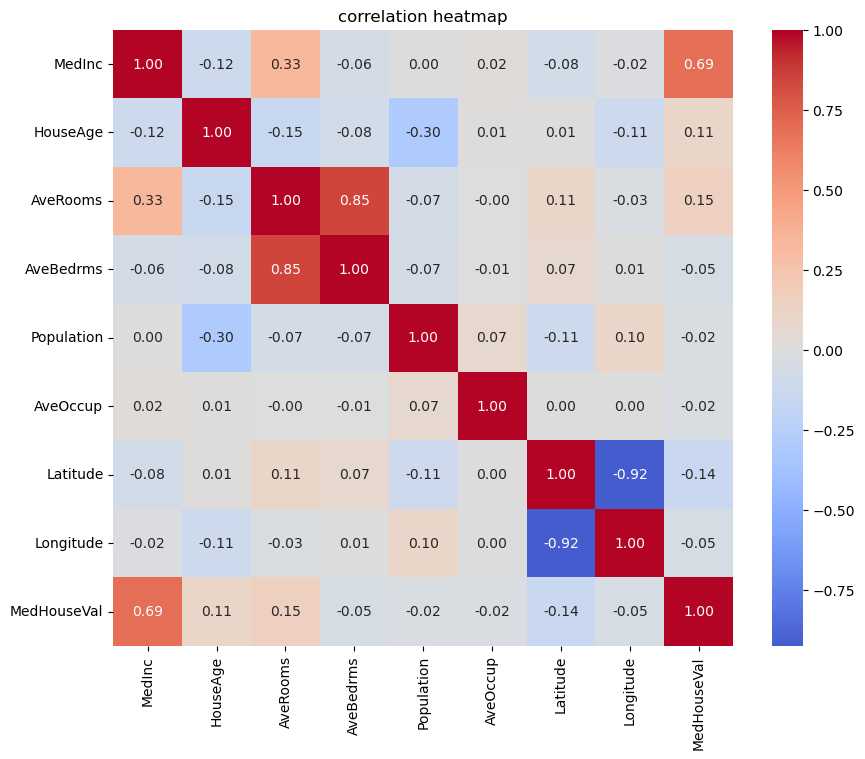


 correlations with house price:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


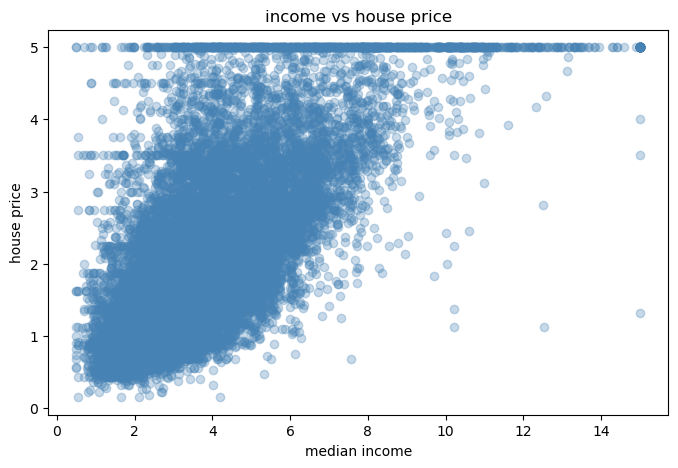

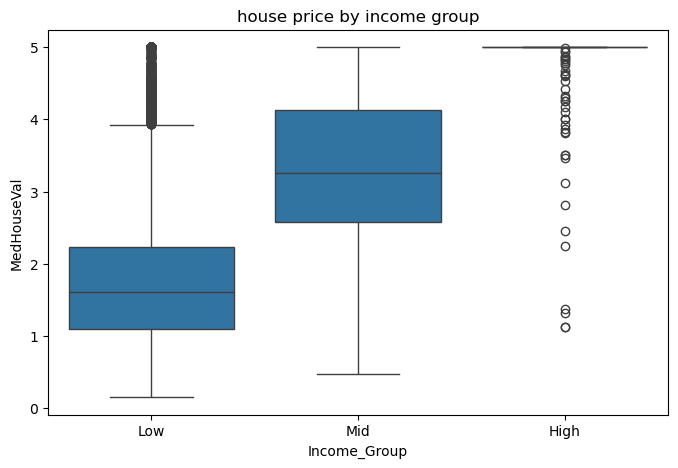

In [5]:
# bivariate EDA
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('correlation heatmap')
plt.show()

#top correlated features with house price
correlations= df.corr()['MedHouseVal'].sort_values(ascending=False)
print("\n correlations with house price:")
print(correlations)

#scatter plot - income vs price (strongest relationship)
plt.figure(figsize=(8,5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3, color='steelblue')
plt.xlabel('median income')
plt.ylabel('house price')
plt.title('income vs house price')
plt.show()

#boxplot - category vs number
df['Income_Group']= pd.cut(df['MedInc'],
                           bins=3, labels=['Low','Mid','High'])
plt.figure(figsize=(8,5))
sns.boxplot(x='Income_Group', y='MedHouseVal', data=df)
plt.title('house price by income group')
plt.show()

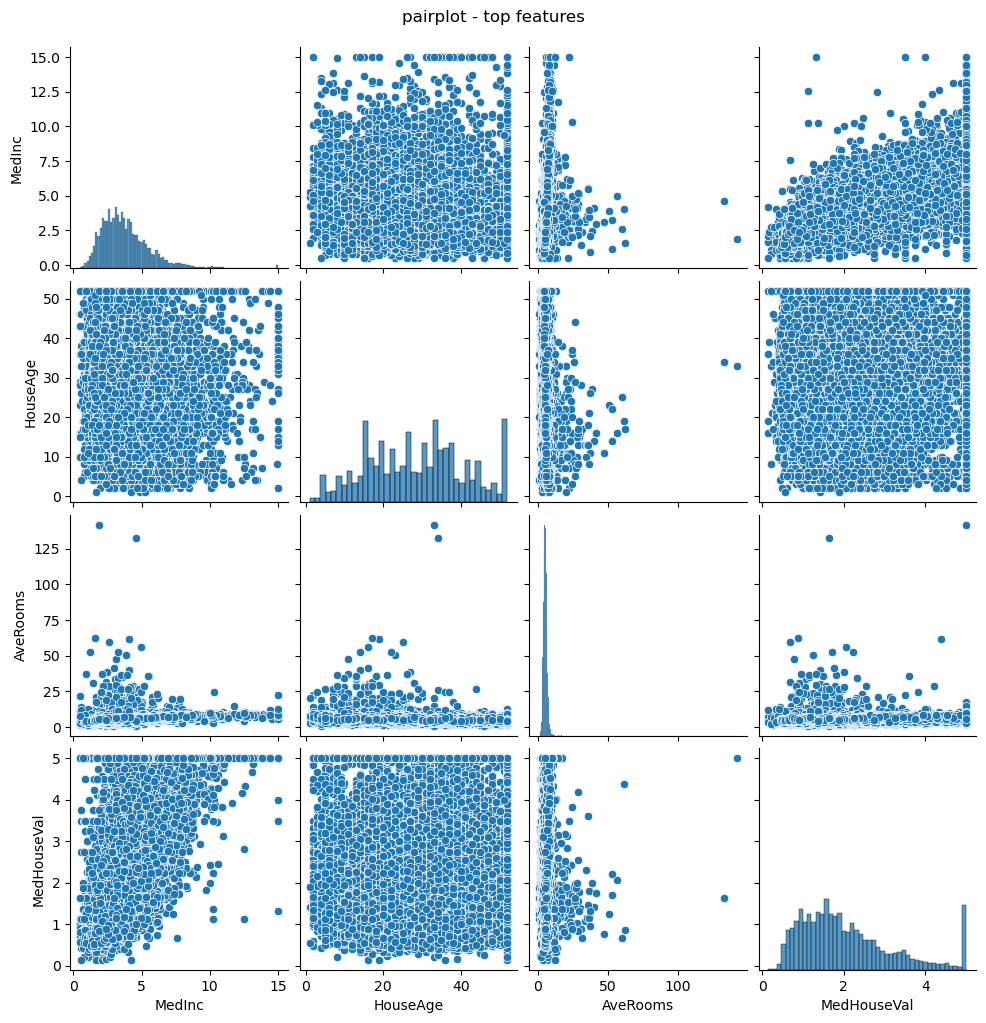

C:\Users\acer\AppData\Local\Temp\ipykernel_12992\1461591819.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot= pd.pivot_table(df,


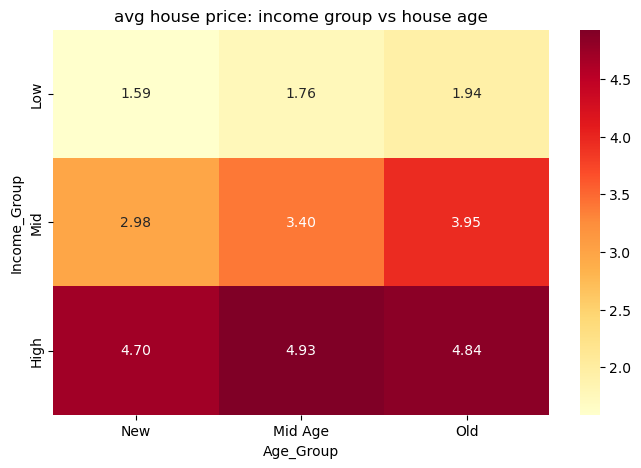

In [6]:
#multivariate EDA
#pairplot - top 4 features
sns.pairplot(df[['MedInc','HouseAge','AveRooms',"MedHouseVal"]],
            diag_kind='hist')
plt.suptitle('pairplot - top features', y=1.02)
plt.show()

#pivot table heatmap
df['Age_Group']=pd.cut(df['HouseAge'],
                       bins=3, labels=['New','Mid Age', 'Old'])

pivot= pd.pivot_table(df,
                      values='MedHouseVal',
                      index='Income_Group',
                      columns='Age_Group',
                      aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('avg house price: income group vs house age')
plt.show()

In [13]:
def quick_eda(df, target=None):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    print("="*50)
    print(f"shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("="*50)

    # missing values
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print("\nmissing values:")
        print(missing)
    else:
        print("\nno missing values")

    # data types
    print("\ndata types:")
    print(df.dtypes.value_counts())

    # basic stats
    print("\nbasic stats:")
    print(df.describe().round(2))

    # correlation with target
    if target is not None:
        if target in df.columns:
            if pd.api.types.is_numeric_dtype(df[target]):
                print(f"\ncorrelations with {target}:")
                corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)
                print(corr)
            else:
                print(f"\ntarget '{target}' is not numeric, skipping correlation")
        else:
            print(f"\ntarget '{target}' not found in dataframe")

    # distributions
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols].hist(figsize=(15,10), bins=30)
    plt.suptitle('all numeric distributions')
    plt.tight_layout()
    plt.show()

    print("\nEDA complete")

    

shape: 20640 rows, 11 columns

no missing values

data types:
float64     9
category    1
category    1
Name: count, dtype: int64

basic stats:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15

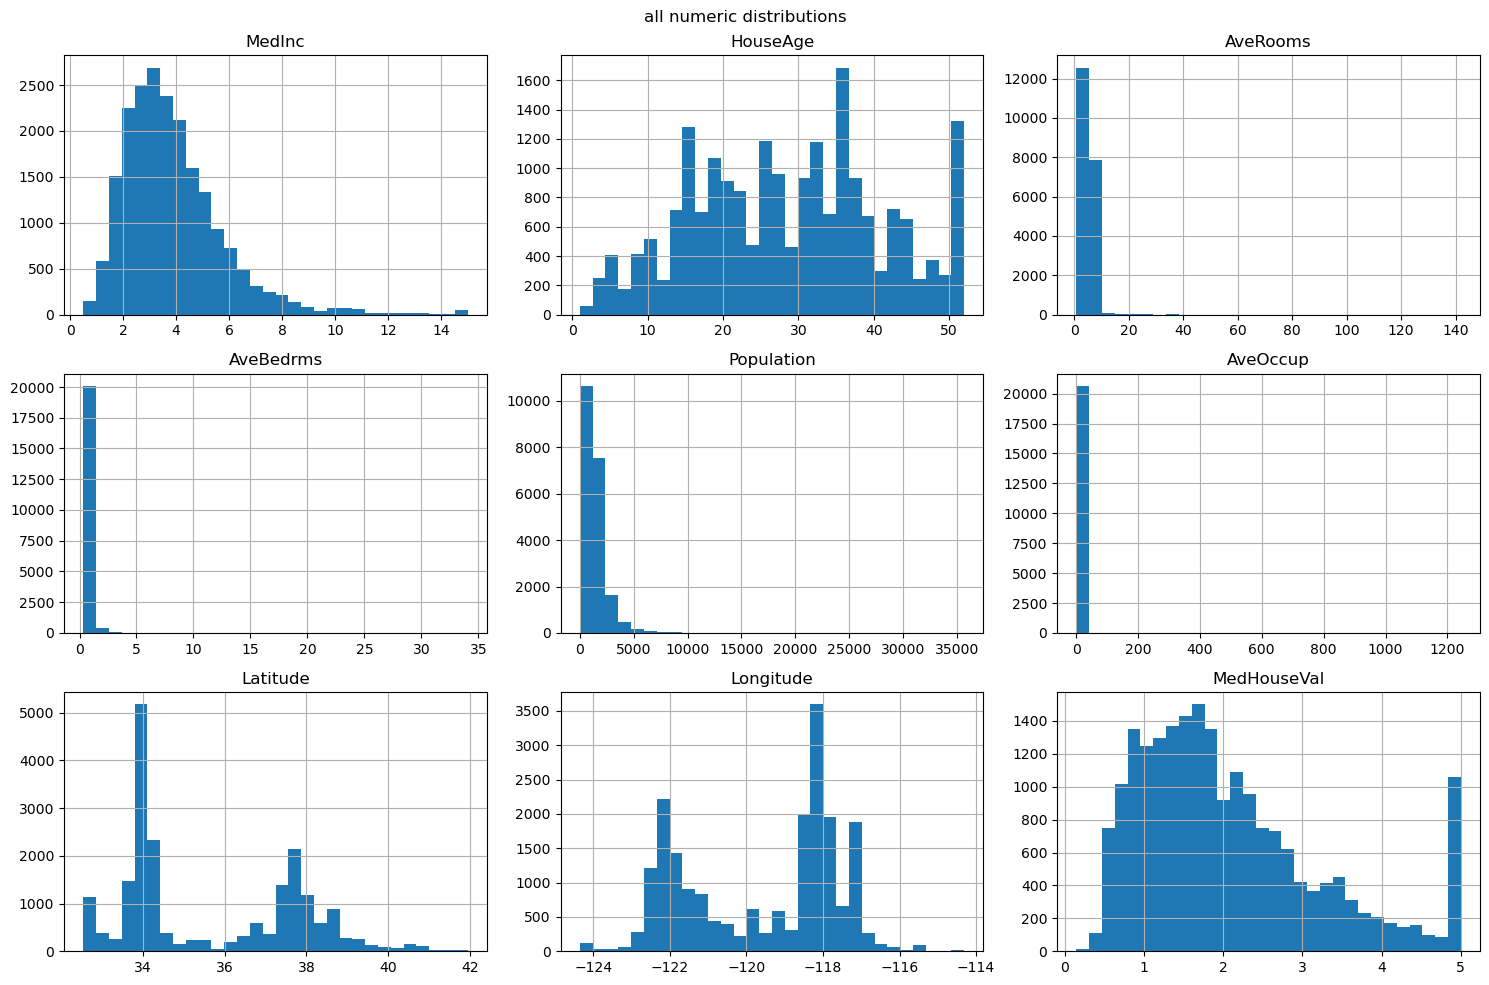


EDA complete


In [14]:
quick_eda(df, target='MedHouseVal')

EDA — 3 LEVELS
──────────────────────────────────────────
Univariate   → one column   (distribution, outliers, missing)
Bivariate    → two columns  (correlation, scatter, boxplot)
Multivariate → many columns (pairplot, pivot heatmap)

WHICH PLOT FOR WHAT?
──────────────────────────────────────────
Distribution of numbers     → histogram
Outliers in numbers         → boxplot
Number vs Number            → scatter plot
All correlations at once    → heatmap
Category vs Number          → boxplot per category
All pairs at once           → pairplot

CORRELATION
──────────────────────────────────────────
+1.0 → perfect positive relationship
 0.0 → no relationship
-1.0 → perfect negative relationship
> 0.7 or < -0.7 → strong (worth investigating)

EDA QUESTIONS TO ALWAYS ASK
──────────────────────────────────────────
1. Any missing values?
2. What are the distributions? Skewed?
3. Any outliers?
4. Which features correlate with target?
5. Any surprising relationships?